### Bag of N grams tutorial

##### Let's first understand how to generate n-grams using CountVectorizer

In [1]:
from sklearn.feature_extraction.text import CountVectorizer
# A small corpus of documents
corpus = [
    "Thor Hathodawala is looking for a job"
]
v=CountVectorizer()
v.fit(corpus)
v.vocabulary_

{'thor': 5, 'hathodawala': 1, 'is': 2, 'looking': 4, 'for': 0, 'job': 3}

In [2]:
v=CountVectorizer(ngram_range=(2,2))
v.fit(corpus)
v.vocabulary_

{'thor hathodawala': 4,
 'hathodawala is': 1,
 'is looking': 2,
 'looking for': 3,
 'for job': 0}

In [3]:
v = CountVectorizer(ngram_range=(1,2))
v.fit(corpus)
v.vocabulary_

{'thor': 9,
 'hathodawala': 2,
 'is': 4,
 'looking': 7,
 'for': 0,
 'job': 6,
 'thor hathodawala': 10,
 'hathodawala is': 3,
 'is looking': 5,
 'looking for': 8,
 'for job': 1}

In [4]:
v = CountVectorizer(ngram_range=(1,3))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 12,
 'hathodawala': 2,
 'is': 5,
 'looking': 9,
 'for': 0,
 'job': 8,
 'thor hathodawala': 13,
 'hathodawala is': 3,
 'is looking': 6,
 'looking for': 10,
 'for job': 1,
 'thor hathodawala is': 14,
 'hathodawala is looking': 4,
 'is looking for': 7,
 'looking for job': 11}

We will not take a simple collection of text documents, preprocess them to remove stop words, lemmatize etc and then generate bag of 1 grams and 2 grams from it

In [5]:
import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm")


    # remove stop words and lemmatize the text
def preprocess(text):
    doc=nlp(text)
    non_stop_lemamatize_tokens=[]
    for token in doc:
        if not token.is_stop and not token.is_punct:
            non_stop_lemamatize_tokens.append(token.lemma_)
    
    return " ".join(non_stop_lemamatize_tokens)


In [6]:
preprocess("Thor ate pizza")

'thor eat pizza'

In [7]:
preprocess("Loki is eating pizza")

'Loki eat pizza'

In [8]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]

In [9]:
preprocessed_corpus=[]
for text in corpus:
    preprocessed_corpus.append(preprocess(text))

preprocessed_corpus
    

['thor eat pizza', 'Loki tall', 'Loki eat pizza']

In [10]:
v=CountVectorizer(ngram_range=(1,2))
v.fit(preprocessed_corpus)
v.vocabulary_

{'thor': 7,
 'eat': 0,
 'pizza': 5,
 'thor eat': 8,
 'eat pizza': 1,
 'loki': 2,
 'tall': 6,
 'loki tall': 4,
 'loki eat': 3}

Now generate bag of n gram vector for few sample documents

In [11]:
v.transform(["Thor eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 1, 1]])

Let's take a document that has out of vocabulary (OOV) term and see how bag of ngram generates vector out of it

In [12]:
v.transform(["Hulk eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 0, 0]])

<img src="thor_hulk.jpg" width=800/>

### News Category Classification Problem

Okay now that we know basics of BAG of n grams vectorizer 😎 It is the time to work on a real problem. Here we want to do a news category classification. We will use bag of n-grams and traing a machine learning model that can categorize any news into one of the following categories,

1. BUSINESS
1. SPORTS
1. CRIME
1. SCIENCE

#### Dataset

Dataset Credits: https://www.kaggle.com/code/hengzheng/news-category-classifier-val-acc-0-65

- This data consists of two columns.
        - Text
        - Category
- Text is a news article
- Category can be one of these 4: 'BUSINESS', 'SPORTS', 'CRIME', 'SCIENCE', to keep things simple I trimmed additional categories from the original dataset

In [13]:
import pandas as pd
df=pd.read_json("news_dataset.json")
df.head()

,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [14]:
df.shape

(12695, 2)

In [15]:
df["category"].value_counts()

category
BUSINESS    4254
SPORTS      4167
CRIME       2893
SCIENCE     1381
Name: count, dtype: int64

### **Handle class imbalance**

As you can see above, SCIENCE category has almost 1/3rd data samples compared to BUSINESS and SPORTS categories. I initially trained a model without handling the imbalanced I saw a lower f1-score for SCIENCE category. Hence we need to address this imbalanced. 

There are various ways of handling class imbalance which I have discussed in this video: https://www.youtube.com/watch?v=JnlM4yLFNuo


Out of those techniques, I will use **undersampling** technique here. 

In undersampling, we take a minor class and sample those many samples from other classes, this means we are not utilizing all the data samples for training and in ML world - Not using all the data for training is considered a SIN! 😵 In real life, you are advised to use a technique such as SMOTE so that you can utilize all of your dataset for the training but since this tutorial is more about bag of n-grams then class imbalance itself, I'd go with a simple technique of undersampling. 

In [16]:
df["category"].unique()

array(['SCIENCE', 'BUSINESS', 'CRIME', 'SPORTS'], dtype=object)

In [17]:
df["category"].nunique()

4

In [18]:
df[df["category"]=="SCIENCE"]

,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
9,Here's Why Coffee Makes You Have To Poop It hi...,SCIENCE
22,Animals Kept In Deep Freeze For 30 Years Broug...,SCIENCE
30,Solstice Time The 12-hour Babylonian solar day...,SCIENCE
...,...,...
12632,New Continent Zealandia Is Discovered Underwat...,SCIENCE
12644,Smartphone Lovers More Likely To Forget Things...,SCIENCE
12669,Ambitious Test On Tap For Real-Life 'Flying Sa...,SCIENCE
12691,This Minivan-Sized Sea Sponge Is Thought To Be...,SCIENCE


In [19]:
min_samples = 1381 # we have these many SCIENCE articles and SCIENCE is our minority class

df_science=df[df["category"]=="SCIENCE"].sample(min_samples,random_state=2025)
df_business=df[df["category"]=="BUSINESS"].sample(min_samples,random_state=2025)
df_crime=df[df["category"]=="CRIME"].sample(min_samples,random_state=2025)
df_sports=df[df["category"]=="SPORTS"].sample(min_samples,random_state=2025)


In [22]:
df_balanced=pd.concat([df_science,df_business,df_crime,df_sports],axis="rows")
df_balanced.head()

,text,category
835,WATCH: Cute Marsupials Parachute Through The A...,SCIENCE
12378,Polar Bears Trap Team Of Scientists Inside Rem...,SCIENCE
3950,Scientists Reveal Secret To Boosting Your Meta...,SCIENCE
764,Meet The Most Powerful Woman In Particle Physi...,SCIENCE
6846,24 Of The Best Astrophotos Of 2014,SCIENCE


In [23]:
df_balanced["category"].value_counts()

category
SCIENCE     1381
BUSINESS    1381
CRIME       1381
SPORTS      1381
Name: count, dtype: int64

**Convert text category to a number**

In [25]:
df_balanced["category"].value_counts()

category
SCIENCE     1381
BUSINESS    1381
CRIME       1381
SPORTS      1381
Name: count, dtype: int64

In [26]:
target={"BUSINESS":0,"SPORTS":1,"CRIME":2,"SCIENCE":3}
df_balanced["category_num"]=df_balanced["category"].map(target)

In [27]:
df_balanced.head()

,text,category,category_num
835,WATCH: Cute Marsupials Parachute Through The A...,SCIENCE,3
12378,Polar Bears Trap Team Of Scientists Inside Rem...,SCIENCE,3
3950,Scientists Reveal Secret To Boosting Your Meta...,SCIENCE,3
764,Meet The Most Powerful Woman In Particle Physi...,SCIENCE,3
6846,24 Of The Best Astrophotos Of 2014,SCIENCE,3


**Build a model with original text (no pre processing)**

In [28]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(df_balanced["text"],df_balanced["category_num"],test_size=0.2,random_state=2025,stratify=df_balanced["category_num"])

In [29]:
print(X_train.shape)
X_train.head()

(4419,)


9917     What The AT&T-Time Warner Merger Will Actually...
6152     Venus Fights To Bitter End, But Loses Quarter-...
2778     Will It Matter? The Pope, the Environment and ...
11120        WATCH: Tebow's Hilarious Spurrier Impression 
7806     The Secret To Being Happy And Loving Your Job ...
Name: text, dtype: object

In [30]:
y_train.value_counts()

category_num
0    1105
1    1105
3    1105
2    1104
Name: count, dtype: int64

In [31]:
y_test.value_counts()

category_num
2    277
3    276
1    276
0    276
Name: count, dtype: int64

**Attempt 1 : Use 1-gram which is nothing but a Bag Of Words (BOW) model**

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

In [35]:
#1. create a pipeline object

In [33]:
steps=[
    ("vectorizer",CountVectorizer()),
    ("classifier",MultinomialNB())
]

In [34]:
model=Pipeline(steps)

In [36]:
#2. fit with X_train and y_train
model.fit(X_train,y_train)

,steps,"[('vectorizer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [37]:
#3. get the predictions for X_test and store it in y_pred
y_pred=model.predict(X_test)

In [39]:
#4. print the classfication report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       276
           1       0.89      0.85      0.87       276
           2       0.89      0.92      0.91       277
           3       0.89      0.83      0.86       276

    accuracy                           0.87      1105
   macro avg       0.88      0.87      0.87      1105
weighted avg       0.88      0.87      0.87      1105



In [40]:
X_test[:5]

7198     Here's The Ugly Truth About How People Use Fac...
1872                      WATCH: Sergio Saves Real Madrid 
10247    Ethiopian Runner Almaz Ayana Just Produced One...
11208    Claressa Shields Is First U.S. Boxer In A Cent...
6059     27 Reasons The Royals Are Becoming America's F...
Name: text, dtype: object

- BUSINESS: 0
- SPORTS: 1
- CRIME: 2
- SCIENCE: 3

In [41]:
y_pred[:5]

array([0, 1, 1, 1, 1])

In [43]:
y_test[:5]

7198     3
1872     1
10247    1
11208    1
6059     1
Name: category_num, dtype: int64

**Attempt 2 : Use 1-gram and bigrams**

In [44]:
#1. create a pipeline object
clf = Pipeline([
    ('vectorizer_1_2_gram', CountVectorizer(ngram_range = (1, 2))),        #using the ngram_range parameter 
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.94      0.85       276
           1       0.93      0.82      0.87       276
           2       0.91      0.90      0.90       277
           3       0.91      0.82      0.86       276

    accuracy                           0.87      1105
   macro avg       0.88      0.87      0.87      1105
weighted avg       0.88      0.87      0.87      1105



**Attempt 3 : Use 1-gram to trigrams**

In [45]:
#1. create a pipeline object
clf = Pipeline([
    ('vectorizer_1_3_grams', CountVectorizer(ngram_range = (1, 3))),        #using the ngram_range parameter 
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.94      0.83       276
           1       0.93      0.82      0.87       276
           2       0.91      0.89      0.90       277
           3       0.90      0.79      0.84       276

    accuracy                           0.86      1105
   macro avg       0.87      0.86      0.86      1105
weighted avg       0.87      0.86      0.86      1105



### Use text pre-processing to remove stop words, punctuations and apply lemmatization

You may wonder, we have not done any text-processing yet to remove stop words, punctuations, apply lemmatization etc. Well we wanted to train the model without any preprocessing first and check the performance. Now we will re-do same thing but with preprocessing of text

In [46]:
df_balanced.head()

,text,category,category_num
835,WATCH: Cute Marsupials Parachute Through The A...,SCIENCE,3
12378,Polar Bears Trap Team Of Scientists Inside Rem...,SCIENCE,3
3950,Scientists Reveal Secret To Boosting Your Meta...,SCIENCE,3
764,Meet The Most Powerful Woman In Particle Physi...,SCIENCE,3
6846,24 Of The Best Astrophotos Of 2014,SCIENCE,3


In [48]:
import spacy
# Load the installed English model
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    doc=nlp(text)
    non_stop_lemmatized_tokens=[]
    for token in doc:
        if not token.is_stop and not token.is_punct:
            non_stop_lemmatized_tokens.append(token.lemma_)
    
    return " ".join(non_stop_lemmatized_tokens)

    

In [49]:
df_balanced["preprocessed_txt"]=df_balanced["text"].apply(preprocess)

In [50]:
df_balanced.head()

,text,category,category_num,preprocessed_txt
835,WATCH: Cute Marsupials Parachute Through The A...,SCIENCE,3,WATCH Cute Marsupials Parachute air Slow Mo
12378,Polar Bears Trap Team Of Scientists Inside Rem...,SCIENCE,3,Polar Bears Trap Team Scientists inside Remote...
3950,Scientists Reveal Secret To Boosting Your Meta...,SCIENCE,3,scientist reveal secret boost Metabolism Sleep
764,Meet The Most Powerful Woman In Particle Physi...,SCIENCE,3,meet powerful woman Particle Physics Fabiola G...
6846,24 Of The Best Astrophotos Of 2014,SCIENCE,3,24 good astrophotos 2014


**Build a model with pre processed text**

In [54]:
X_train,X_test,y_train,y_test=train_test_split(df_balanced["preprocessed_txt"],df_balanced["category_num"],test_size=0.2,random_state=2025,stratify=df_balanced["category_num"])

In [55]:
print(X_train.shape)
X_train.head()

(4419,)


9917     AT&T Time Warner Merger actually service analy...
6152     Venus fight bitter end lose Quarter Final Batt...
2778     matter Pope Environment Tips Pope action clima...
11120            WATCH Tebow Hilarious Spurrier impression
7806     secret happy love Job way happiness happiness way
Name: preprocessed_txt, dtype: object

In [56]:
y_train.value_counts()

category_num
0    1105
1    1105
3    1105
2    1104
Name: count, dtype: int64

In [57]:
y_test.value_counts()

category_num
2    277
3    276
1    276
0    276
Name: count, dtype: int64

In [58]:
#1. create a pipeline object
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range = (1, 2))),        #using the ngram_range parameter 
    ('Multi NB', MultinomialNB())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88       276
           1       0.92      0.91      0.91       276
           2       0.86      0.94      0.90       277
           3       0.92      0.83      0.87       276

    accuracy                           0.89      1105
   macro avg       0.89      0.89      0.89      1105
weighted avg       0.89      0.89      0.89      1105



If you compare above classification report for (1,2) gram with the one from unprocessed text, you will find some improvement in the model that uses preprocessed cleaned up text. Hence we can conclude that for this particular problem using preprocessing (removing stop words, lemmatization) is improving the performance of the model

**Plot confusion matrix**

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[242,   9,  15,  10],
       [ 10, 230,  29,   8],
       [ 15,   1, 255,   5],
       [ 34,  10,   8, 224]], dtype=int64)

Text(69.0, 0.5, 'Truth')

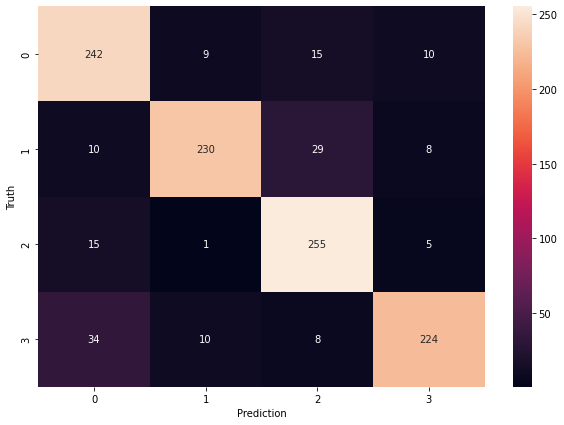

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')